Title :Design RNN or its variant including LSTM or GRU a) Select a suitable...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("sentiment_large.csv")
df.head()

,text,sentiment
0,Exceeded my expectations!,positive
1,I regret buying this.,negative
2,Exceeded my expectations!,positive
3,I love this product!,positive
4,Really happy with the purchase.,positive


In [3]:
df['sentiment'].value_counts()

sentiment
positive    600
negative    600
Name: count, dtype: int64

In [4]:
texts = df["text"].astype(str).values
labels = df["sentiment"].values

In [5]:
le = LabelEncoder()
labels = le.fit_transform(labels) # positive=1, negative=0

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = 20

In [7]:
X = pad_sequences(sequences, maxlen=max_len)
y = labels

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [9]:
model = Sequential([
Embedding(10000, 128), # removed input_length
LSTM(128, return_sequences=False),
Dropout(0.3),
Dense(64, activation='relu'),
Dense(1, activation='sigmoid')
])
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,419,905 (5.42 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
X_train, y_train,
validation_data=(X_test, y_test),
epochs=15,
batch_size=64
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.7792 - loss: 0.6550 - val_accuracy: 0.9333 - val_loss: 0.5425
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9135 - loss: 0.3499 - val_accuracy: 0.8875 - val_loss: 0.1891
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9854 - loss: 0.0986 - val_accuracy: 1.0000 - val_loss: 0.0300
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 0.0171 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 5.4526e-04
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 1.0000 - loss: 7.4594e-04 - val_accuracy: 1.0000 - val_loss: 3.3722e-04
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 6.0101e-04 - val_acc

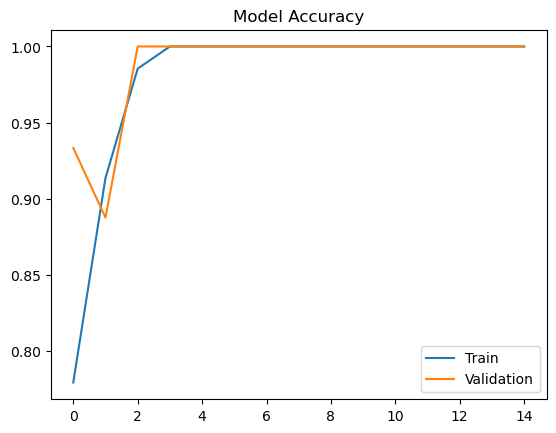

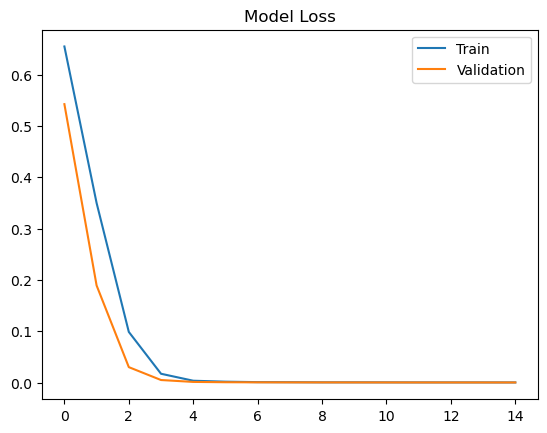

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train", "Validation"])
plt.show()


In [12]:
sample = ["Good value for money"]
seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=10)
pred = model.predict(pad)
print("Positive" if pred > 0.4 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Positive
